In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import time
import os
import random
from scipy import stats

📝 Создаём синтетическую пару изображений...
✅ Синтетические изображения созданы


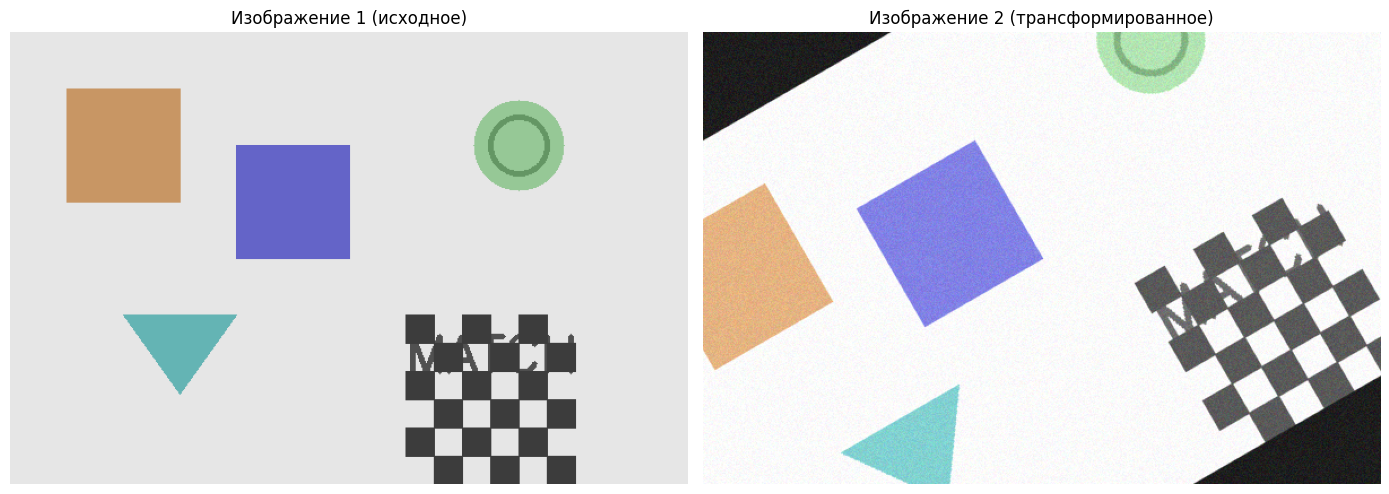

In [7]:
# Загружаем два изображения для сопоставления
img1_path = ''
img2_path = ''

def load_or_create_image_pair():
    """Загружает или создаёт пару изображений для сопоставления"""

    # Пытаемся загрузить готовые изображения
    if os.path.exists(img1_path) and os.path.exists(img2_path):
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        print(f"✅ Изображения загружены: {img1_path}, {img2_path}")
        return img1, img2

    print("📝 Создаём синтетическую пару изображений...")

    # Создаём базовое изображение
    img1 = np.ones((400, 600, 3), dtype=np.uint8) * 230

    # Добавляем узнаваемые объекты
    # Прямоугольники
    cv2.rectangle(img1, (50, 50), (150, 150), (100, 150, 200), -1)
    cv2.rectangle(img1, (200, 100), (300, 200), (200, 100, 100), -1)

    # Круги
    cv2.circle(img1, (450, 100), 40, (150, 200, 150), -1)
    cv2.circle(img1, (450, 100), 25, (100, 150, 100), 3)

    # Треугольник
    triangle = np.array([[100, 250], [200, 250], [150, 320]], np.int32)
    cv2.fillPoly(img1, [triangle], (180, 180, 100))

    # Текст
    cv2.putText(img1, 'MATCH', (350, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (80, 80, 80), 3)

    # Шахматная доска для углов
    square_size = 25
    for i in range(6):
        for j in range(6):
            if (i + j) % 2 == 0:
                y1 = 250 + i * square_size
                x1 = 350 + j * square_size
                cv2.rectangle(img1, (x1, y1), (x1+square_size, y1+square_size), (60, 60, 60), -1)

    # Создаём второе изображение с трансформацией
    height, width = img1.shape[:2]
    center = (width // 2, height // 2)

    # Поворот на 30° + масштаб 1.2
    M = cv2.getRotationMatrix2D(center, 30, 1.2)
    img2 = cv2.warpAffine(img1, M, (width, height))

    # Добавляем изменение яркости
    img2 = np.clip(img2.astype(np.int16) + 30, 0, 255).astype(np.uint8)

    # Добавляем шум
    noise = np.random.randint(-15, 15, img2.shape, dtype=np.int16)
    img2 = np.clip(img2.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    print("✅ Синтетические изображения созданы")
    return img1, img2

img1, img2 = load_or_create_image_pair()

# Преобразуем в grayscale
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Визуализируем исходные изображения
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0].set_title('Изображение 1 (исходное)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1].set_title('Изображение 2 (трансформированное)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

ТЕСТИРОВАНИЕ RANSAC
Тестирование RANSAC на синтетических данных...
Всего точек: 50, из них выбросов: 15
Найдено inliers: 35
Доля inliers: 70.00%
Ошибка оценки гомографии: 0.0000


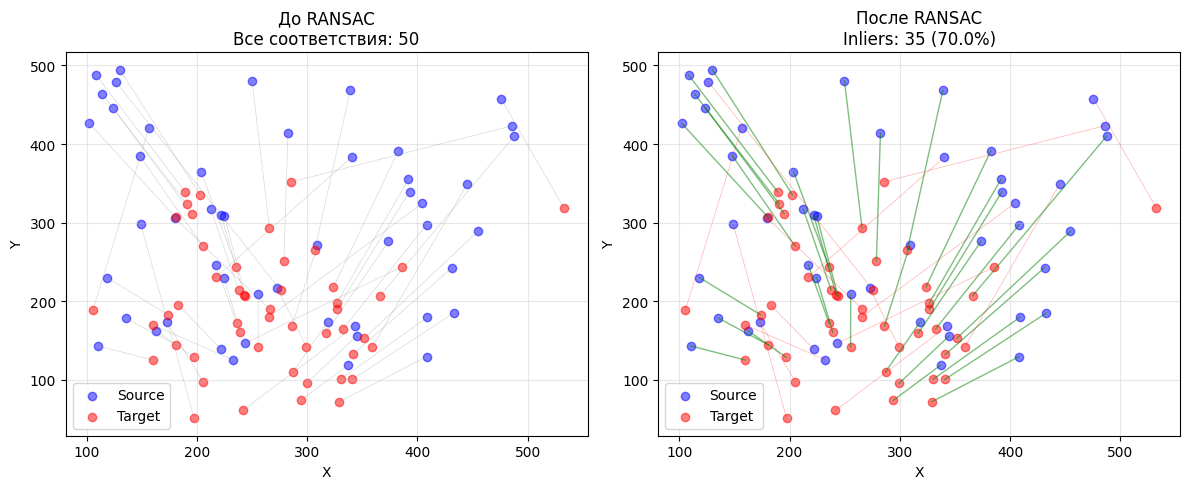

In [8]:
# ============================================
# 1. РЕАЛИЗАЦИЯ RANSAC ДЛЯ ФИЛЬТРАЦИИ ВЫБРОСОВ
# ============================================

def compute_homography(src_points, dst_points):
    """
    Вычисляет матрицу гомографии по 4 парам точек.
    Использует метод DLT (Direct Linear Transform).
    """
    if len(src_points) != 4 or len(dst_points) != 4:
        raise ValueError("Нужно ровно 4 пары точек")

    A = []
    for i in range(4):
        x, y = src_points[i]
        xp, yp = dst_points[i]

        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

    A = np.array(A, dtype=np.float64)

    # Вычисляем SVD
    U, S, Vt = np.linalg.svd(A)

    # Решение - последний столбец V (или последняя строка Vt)
    H = Vt[-1].reshape(3, 3)

    # Нормализуем матрицу
    H = H / H[2, 2]

    return H

def compute_reprojection_error(H, src_points, dst_points):
    """
    Вычисляет ошибку репроекции для точек.
    """
    # Преобразуем src_points в однородные координаты
    src_homogeneous = np.column_stack([src_points, np.ones(len(src_points))])

    # Применяем гомографию
    dst_projected_homogeneous = np.dot(H, src_homogeneous.T).T

    # Нормализуем
    dst_projected = dst_projected_homogeneous[:, :2] / dst_projected_homogeneous[:, 2:3]

    # Вычисляем евклидово расстояние
    errors = np.linalg.norm(dst_projected - dst_points, axis=1)

    return errors

def ransac_filter_matches(kp1, kp2, matches, n_iterations=1000, threshold=5.0, min_inliers=10):

    if len(matches) < 4:
        return None, [], 0.0

    # Преобразуем ключевые точки в массивы координат
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 2)

    best_H = None
    best_inliers = []
    best_inlier_count = 0

    for i in range(n_iterations):
        # 1. Случайно выбираем 4 соответствия
        if len(matches) < 4:
            continue

        indices = random.sample(range(len(matches)), 4)

        # 2. Вычисляем гомографию по 4 точкам
        try:
            H = compute_homography(src_pts[indices], dst_pts[indices])
        except:
            continue

        # 3. Вычисляем ошибку репроекции для всех точек
        errors = compute_reprojection_error(H, src_pts, dst_pts)

        # 4. Определяем inliers (точки с ошибкой ниже порога)
        inlier_indices = np.where(errors < threshold)[0]
        inlier_count = len(inlier_indices)

        # 5. Сохраняем лучшую модель
        if inlier_count > best_inlier_count and inlier_count >= min_inliers:
            best_inlier_count = inlier_count
            best_H = H.copy()
            best_inliers = inlier_indices

    # Формируем список inlier соответствий
    inlier_matches = [matches[i] for i in best_inliers]
    inlier_ratio = best_inlier_count / len(matches) if len(matches) > 0 else 0.0

    return best_H, inlier_matches, inlier_ratio

def test_ransac_on_synthetic_data():
    """
    Тестирование RANSAC на синтетических данных.
    """
    # Генерируем синтетические данные
    np.random.seed(42)

    # Истинная гомография
    true_H = np.array([[1.0, 0.2, 50],
                      [-0.1, 0.9, 30],
                      [0.001, 0.0005, 1.0]])

    # Генерируем исходные точки
    n_points = 50
    src_points = np.random.rand(n_points, 2) * 400 + 100  # Точки в области [100, 500]

    # Преобразуем с помощью истинной гомографии
    src_homogeneous = np.column_stack([src_points, np.ones(n_points)])
    dst_projected = np.dot(true_H, src_homogeneous.T).T
    dst_points = dst_projected[:, :2] / dst_projected[:, 2:3]

    # Добавляем шум к некоторым точкам (outliers)
    n_outliers = 15
    outlier_indices = np.random.choice(n_points, n_outliers, replace=False)
    dst_points[outlier_indices] += np.random.randn(n_outliers, 2) * 100

    # Создаем ключевые точки и соответствия
    kp1 = [cv2.KeyPoint(x, y, 10) for (x, y) in src_points]
    kp2 = [cv2.KeyPoint(x, y, 10) for (x, y) in dst_points]

    matches = []
    for i in range(n_points):
        match = cv2.DMatch()
        match.queryIdx = i
        match.trainIdx = i
        match.distance = 0
        matches.append(match)

    # Применяем RANSAC
    print("Тестирование RANSAC на синтетических данных...")
    print(f"Всего точек: {n_points}, из них выбросов: {n_outliers}")

    H_ransac, inlier_matches, inlier_ratio = ransac_filter_matches(
        kp1, kp2, matches, n_iterations=500, threshold=10.0
    )

    print(f"Найдено inliers: {len(inlier_matches)}")
    print(f"Доля inliers: {inlier_ratio:.2%}")

    if H_ransac is not None:
        # Вычисляем ошибку оценки гомографии
        H_error = np.linalg.norm(H_ransac - true_H) / np.linalg.norm(true_H)
        print(f"Ошибка оценки гомографии: {H_error:.4f}")

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # До RANSAC
    axes[0].scatter(src_points[:, 0], src_points[:, 1], c='blue', label='Source', alpha=0.5)
    axes[0].scatter(dst_points[:, 0], dst_points[:, 1], c='red', label='Target', alpha=0.5)

    # Соединяем соответствия
    for i in range(n_points):
        axes[0].plot([src_points[i, 0], dst_points[i, 0]],
                     [src_points[i, 1], dst_points[i, 1]],
                     'gray', alpha=0.3, linewidth=0.5)

    axes[0].set_title(f'До RANSAC\nВсе соответствия: {n_points}')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # После RANSAC
    axes[1].scatter(src_points[:, 0], src_points[:, 1], c='blue', label='Source', alpha=0.5)
    axes[1].scatter(dst_points[:, 0], dst_points[:, 1], c='red', label='Target', alpha=0.5)

    # Выделяем inliers и outliers
    inlier_indices = [m.queryIdx for m in inlier_matches]
    outlier_indices = [i for i in range(n_points) if i not in inlier_indices]

    # Рисуем inliers зеленым
    for i in inlier_indices:
        axes[1].plot([src_points[i, 0], dst_points[i, 0]],
                     [src_points[i, 1], dst_points[i, 1]],
                     'green', alpha=0.5, linewidth=1)

    # Рисуем outliers красным
    for i in outlier_indices:
        axes[1].plot([src_points[i, 0], dst_points[i, 0]],
                     [src_points[i, 1], dst_points[i, 1]],
                     'red', alpha=0.3, linewidth=0.5)

    axes[1].set_title(f'После RANSAC\nInliers: {len(inlier_matches)} ({inlier_ratio:.1%})')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return H_ransac, inlier_matches, inlier_ratio

# Тестируем RANSAC
print("="*60)
print("ТЕСТИРОВАНИЕ RANSAC")
print("="*60)
ransac_result = test_ransac_on_synthetic_data()



ОПТИМИЗАЦИЯ ПАРАМЕТРОВ FLANN

ОПТИМИЗАЦИЯ FLANN ДЛЯ SIFT
Лучшие параметры для SIFT:
  Trees: 1
  Checks: 200
  Время: 0.0001 сек
  Соответствия: 16
  Качество (соответствий/сек): 132104.1


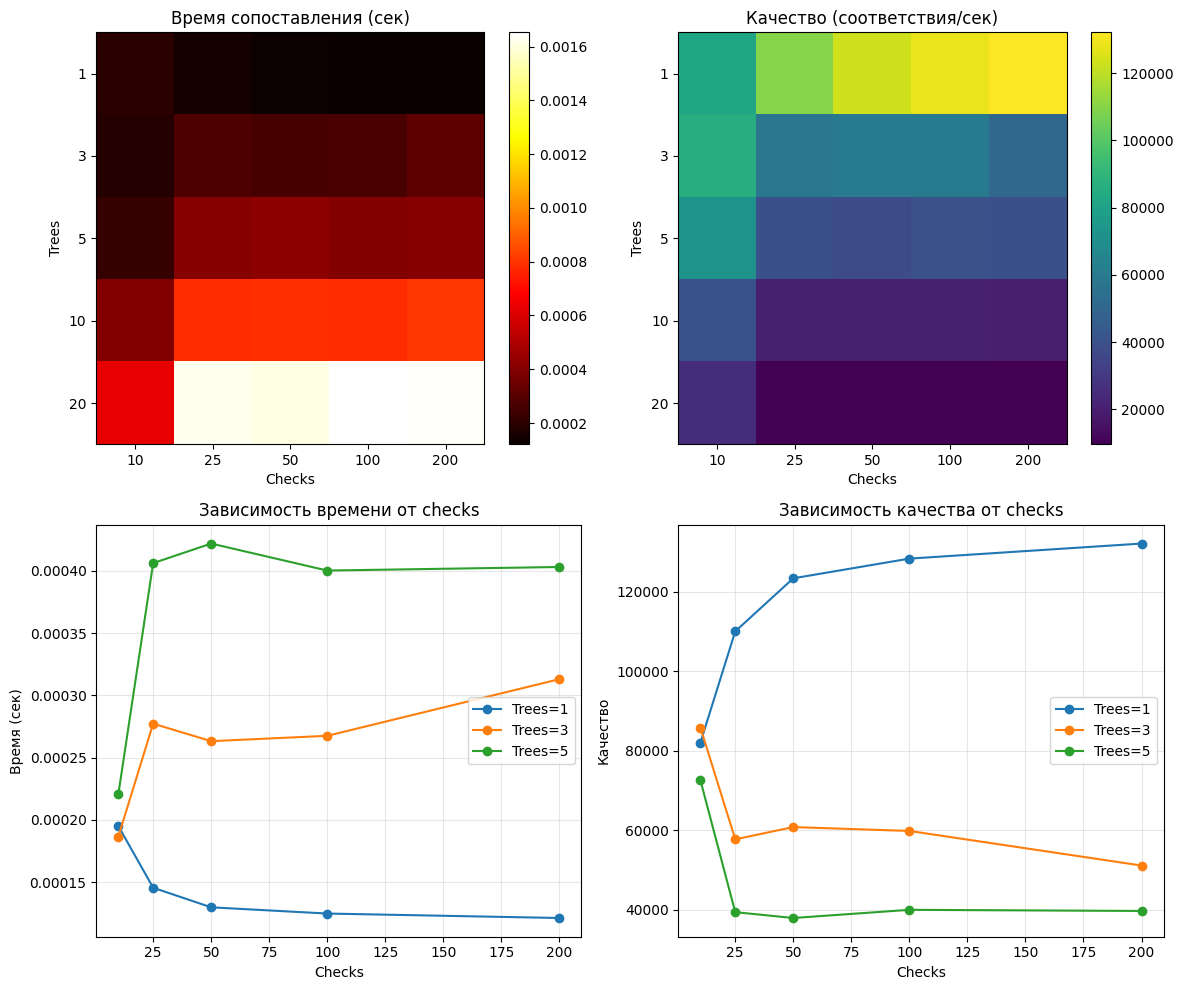


ОПТИМИЗАЦИЯ FLANN ДЛЯ ORB
Лучшие параметры для ORB:
  Table number: 4
  Key size: 15
  Multi-probe level: 1
  Время: 0.0011 сек
  Соответствия: 28
  Качество (соответствий/сек): 25142.5


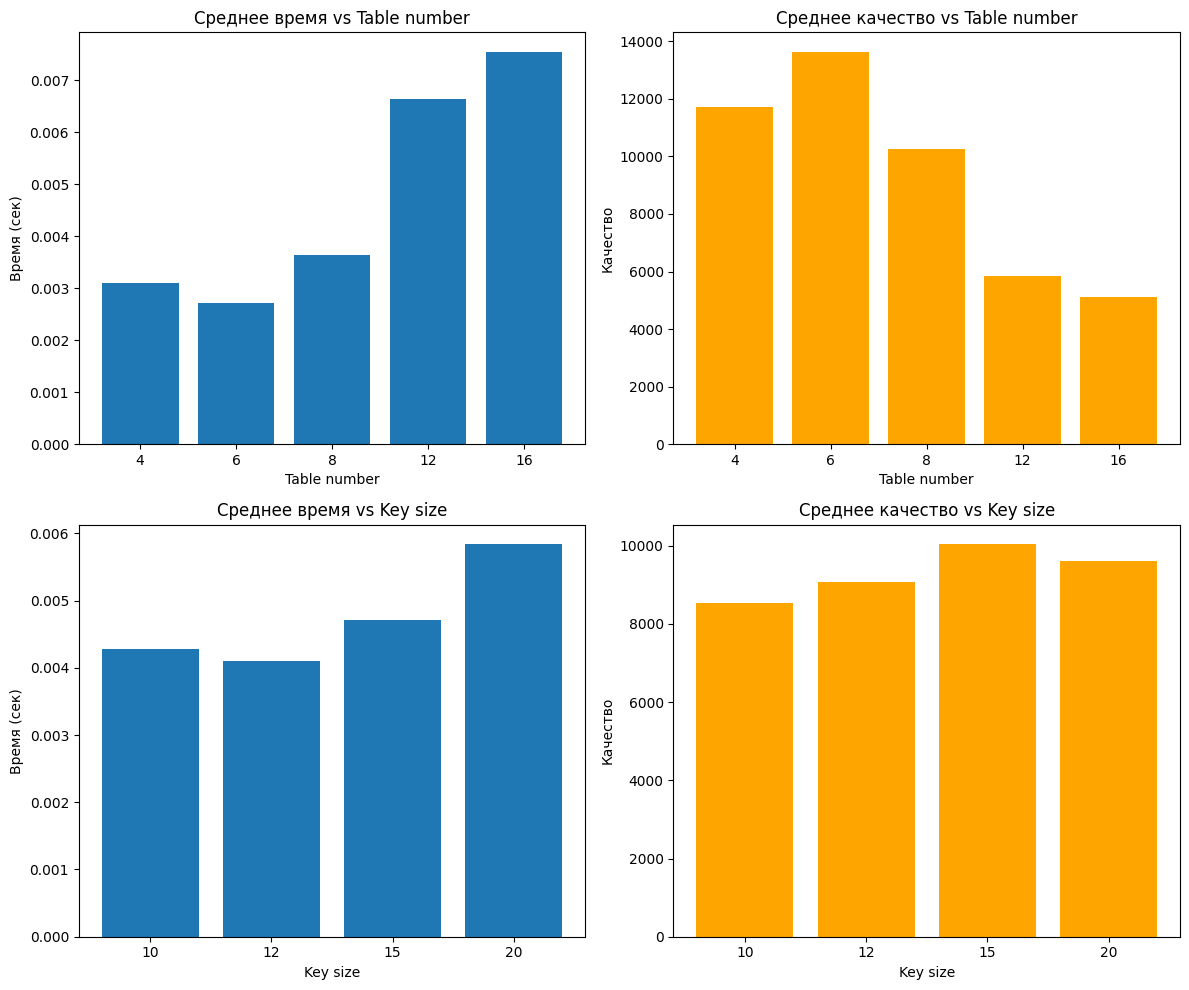

In [9]:
# ============================================
# 2. ОПТИМИЗАЦИЯ ПАРАМЕТРОВ FLANN
# ============================================

def optimize_flann_parameters():
    """
    Оптимизация параметров FLANN для различных детекторов.
    """
    # Создаем тестовые изображения
    img1 = np.zeros((400, 400), dtype=np.uint8)
    img2 = np.zeros((400, 400), dtype=np.uint8)

    # Рисуем тестовые объекты
    cv2.rectangle(img1, (50, 50), (150, 150), 200, -1)
    cv2.circle(img1, (300, 100), 40, 180, -1)
    cv2.ellipse(img1, (200, 300), (50, 30), 30, 0, 360, 150, -1)

    # Второе изображение с трансформацией
    M = cv2.getRotationMatrix2D((200, 200), 15, 1.0)
    img2 = cv2.warpAffine(img1, M, (400, 400))
    img2 = cv2.GaussianBlur(img2, (3, 3), 1)

    # Инициализируем детекторы
    try:
        sift = cv2.SIFT_create()
        orb = cv2.ORB_create(nfeatures=500)
    except:
        print("Ошибка инициализации детекторов")
        return

    # Детектируем ключевые точки
    kp1_sift, des1_sift = sift.detectAndCompute(img1, None)
    kp2_sift, des2_sift = sift.detectAndCompute(img2, None)

    kp1_orb, des1_orb = orb.detectAndCompute(img1, None)
    kp2_orb, des2_orb = orb.detectAndCompute(img2, None)

    # Параметры для оптимизации
    sift_params_grid = {
        'trees': [1, 3, 5, 10, 20],
        'checks': [10, 25, 50, 100, 200]
    }

    orb_params_grid = {
        'table_number': [4, 6, 8, 12, 16],
        'key_size': [10, 12, 15, 20],
        'multi_probe_level': [1, 2, 3]
    }

    def evaluate_flann_params(detector_name, des1, des2, params, param_grid):
        """
        Оценка параметров FLANN.
        """
        results = []

        if detector_name == 'SIFT':
            for trees in param_grid['trees']:
                for checks in param_grid['checks']:
                    # Настройка FLANN для SIFT
                    FLANN_INDEX_KDTREE = 1
                    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=trees)
                    search_params = dict(checks=checks)

                    try:
                        flann = cv2.FlannBasedMatcher(index_params, search_params)

                        # Измеряем время
                        start_time = time.time()
                        matches = flann.knnMatch(des1, des2, k=2)
                        match_time = time.time() - start_time

                        # Применяем тест отношения Лоу
                        good_matches = []
                        for m, n in matches:
                            if m.distance < 0.75 * n.distance:
                                good_matches.append(m)

                        # Сохраняем результаты
                        results.append({
                            'trees': trees,
                            'checks': checks,
                            'time': match_time,
                            'matches': len(good_matches),
                            'quality': len(good_matches) / match_time if match_time > 0 else 0
                        })
                    except:
                        continue

        elif detector_name == 'ORB':
            for table_number in param_grid['table_number']:
                for key_size in param_grid['key_size']:
                    for multi_probe_level in param_grid['multi_probe_level']:
                        # Настройка FLANN для ORB
                        FLANN_INDEX_LSH = 6
                        index_params = dict(
                            algorithm=FLANN_INDEX_LSH,
                            table_number=table_number,
                            key_size=key_size,
                            multi_probe_level=multi_probe_level
                        )
                        search_params = dict(checks=50)

                        try:
                            flann = cv2.FlannBasedMatcher(index_params, search_params)

                            # Измеряем время
                            start_time = time.time()
                            matches = flann.knnMatch(des1, des2, k=2)
                            match_time = time.time() - start_time

                            # Применяем тест отношения Лоу
                            good_matches = []
                            for m, n in matches:
                                if m.distance < 0.75 * n.distance:
                                    good_matches.append(m)

                            # Сохраняем результаты
                            results.append({
                                'table_number': table_number,
                                'key_size': key_size,
                                'multi_probe_level': multi_probe_level,
                                'time': match_time,
                                'matches': len(good_matches),
                                'quality': len(good_matches) / match_time if match_time > 0 else 0
                            })
                        except:
                            continue

        return results

    # Оптимизация для SIFT
    print("\n" + "="*60)
    print("ОПТИМИЗАЦИЯ FLANN ДЛЯ SIFT")
    print("="*60)

    sift_results = evaluate_flann_params('SIFT', des1_sift, des2_sift,
                                         sift_params_grid, sift_params_grid)

    if sift_results:
        # Находим лучшие параметры по качеству (matches/time)
        sift_best = max(sift_results, key=lambda x: x['quality'])

        print(f"Лучшие параметры для SIFT:")
        print(f"  Trees: {sift_best['trees']}")
        print(f"  Checks: {sift_best['checks']}")
        print(f"  Время: {sift_best['time']:.4f} сек")
        print(f"  Соответствия: {sift_best['matches']}")
        print(f"  Качество (соответствий/сек): {sift_best['quality']:.1f}")

        # Визуализация результатов
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # Подготавливаем данные для визуализации
        trees = sorted(set(r['trees'] for r in sift_results))
        checks = sorted(set(r['checks'] for r in sift_results))

        # Матрица времени
        time_matrix = np.zeros((len(trees), len(checks)))
        quality_matrix = np.zeros((len(trees), len(checks)))

        for r in sift_results:
            i = trees.index(r['trees'])
            j = checks.index(r['checks'])
            time_matrix[i, j] = r['time']
            quality_matrix[i, j] = r['quality']

        # График времени
        im1 = axes[0, 0].imshow(time_matrix, cmap='hot', aspect='auto')
        axes[0, 0].set_title('Время сопоставления (сек)')
        axes[0, 0].set_xlabel('Checks')
        axes[0, 0].set_ylabel('Trees')
        axes[0, 0].set_xticks(range(len(checks)))
        axes[0, 0].set_xticklabels(checks)
        axes[0, 0].set_yticks(range(len(trees)))
        axes[0, 0].set_yticklabels(trees)
        plt.colorbar(im1, ax=axes[0, 0])

        # График качества
        im2 = axes[0, 1].imshow(quality_matrix, cmap='viridis', aspect='auto')
        axes[0, 1].set_title('Качество (соответствия/сек)')
        axes[0, 1].set_xlabel('Checks')
        axes[0, 1].set_ylabel('Trees')
        axes[0, 1].set_xticks(range(len(checks)))
        axes[0, 1].set_xticklabels(checks)
        axes[0, 1].set_yticks(range(len(trees)))
        axes[0, 1].set_yticklabels(trees)
        plt.colorbar(im2, ax=axes[0, 1])

        # График зависимости времени от checks
        axes[1, 0].set_title('Зависимость времени от checks')
        for tree_val in trees[:3]:  # Показываем только первые 3 значения trees
            subset = [r for r in sift_results if r['trees'] == tree_val]
            checks_vals = [r['checks'] for r in subset]
            time_vals = [r['time'] for r in subset]
            axes[1, 0].plot(checks_vals, time_vals, 'o-', label=f'Trees={tree_val}')
        axes[1, 0].set_xlabel('Checks')
        axes[1, 0].set_ylabel('Время (сек)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # График зависимости качества от checks
        axes[1, 1].set_title('Зависимость качества от checks')
        for tree_val in trees[:3]:
            subset = [r for r in sift_results if r['trees'] == tree_val]
            checks_vals = [r['checks'] for r in subset]
            quality_vals = [r['quality'] for r in subset]
            axes[1, 1].plot(checks_vals, quality_vals, 'o-', label=f'Trees={tree_val}')
        axes[1, 1].set_xlabel('Checks')
        axes[1, 1].set_ylabel('Качество')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # Оптимизация для ORB
    print("\n" + "="*60)
    print("ОПТИМИЗАЦИЯ FLANN ДЛЯ ORB")
    print("="*60)

    orb_results = evaluate_flann_params('ORB', des1_orb, des2_orb,
                                        orb_params_grid, orb_params_grid)

    if orb_results:
        # Находим лучшие параметры
        orb_best = max(orb_results, key=lambda x: x['quality'])

        print(f"Лучшие параметры для ORB:")
        print(f"  Table number: {orb_best['table_number']}")
        print(f"  Key size: {orb_best['key_size']}")
        print(f"  Multi-probe level: {orb_best['multi_probe_level']}")
        print(f"  Время: {orb_best['time']:.4f} сек")
        print(f"  Соответствия: {orb_best['matches']}")
        print(f"  Качество (соответствий/сек): {orb_best['quality']:.1f}")

        # Анализ влияния каждого параметра
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # Влияние table_number
        table_nums = sorted(set(r['table_number'] for r in orb_results))
        table_avg_time = []
        table_avg_quality = []

        for tn in table_nums:
            subset = [r for r in orb_results if r['table_number'] == tn]
            if subset:
                avg_time = np.mean([r['time'] for r in subset])
                avg_quality = np.mean([r['quality'] for r in subset])
                table_avg_time.append(avg_time)
                table_avg_quality.append(avg_quality)

        axes[0, 0].bar(range(len(table_nums)), table_avg_time)
        axes[0, 0].set_title('Среднее время vs Table number')
        axes[0, 0].set_xlabel('Table number')
        axes[0, 0].set_ylabel('Время (сек)')
        axes[0, 0].set_xticks(range(len(table_nums)))
        axes[0, 0].set_xticklabels(table_nums)

        axes[0, 1].bar(range(len(table_nums)), table_avg_quality, color='orange')
        axes[0, 1].set_title('Среднее качество vs Table number')
        axes[0, 1].set_xlabel('Table number')
        axes[0, 1].set_ylabel('Качество')
        axes[0, 1].set_xticks(range(len(table_nums)))
        axes[0, 1].set_xticklabels(table_nums)

        # Влияние key_size
        key_sizes = sorted(set(r['key_size'] for r in orb_results))
        key_avg_time = []
        key_avg_quality = []

        for ks in key_sizes:
            subset = [r for r in orb_results if r['key_size'] == ks]
            if subset:
                avg_time = np.mean([r['time'] for r in subset])
                avg_quality = np.mean([r['quality'] for r in subset])
                key_avg_time.append(avg_time)
                key_avg_quality.append(avg_quality)

        axes[1, 0].bar(range(len(key_sizes)), key_avg_time)
        axes[1, 0].set_title('Среднее время vs Key size')
        axes[1, 0].set_xlabel('Key size')
        axes[1, 0].set_ylabel('Время (сек)')
        axes[1, 0].set_xticks(range(len(key_sizes)))
        axes[1, 0].set_xticklabels(key_sizes)

        axes[1, 1].bar(range(len(key_sizes)), key_avg_quality, color='orange')
        axes[1, 1].set_title('Среднее качество vs Key size')
        axes[1, 1].set_xlabel('Key size')
        axes[1, 1].set_ylabel('Качество')
        axes[1, 1].set_xticks(range(len(key_sizes)))
        axes[1, 1].set_xticklabels(key_sizes)

        plt.tight_layout()
        plt.show()

    return sift_results, orb_results

# Оптимизируем параметры FLANN
print("\n" + "="*60)
print("ОПТИМИЗАЦИЯ ПАРАМЕТРОВ FLANN")
print("="*60)
flann_optimization_results = optimize_flann_parameters()


МИНИ-ПРОЕКТ: ПОИСК ОБЪЕКТА НА СЦЕНЕ


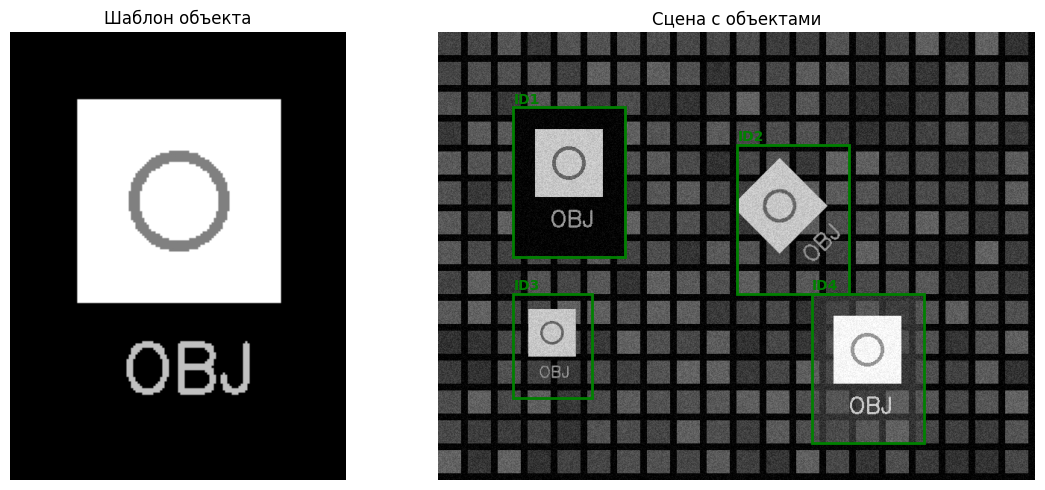

Найдено ключевых точек:
  Шаблон: 58
  Сцена: 3746
Найдено хороших соответствий: 35
Inliers после RANSAC: 21 (60.0%)


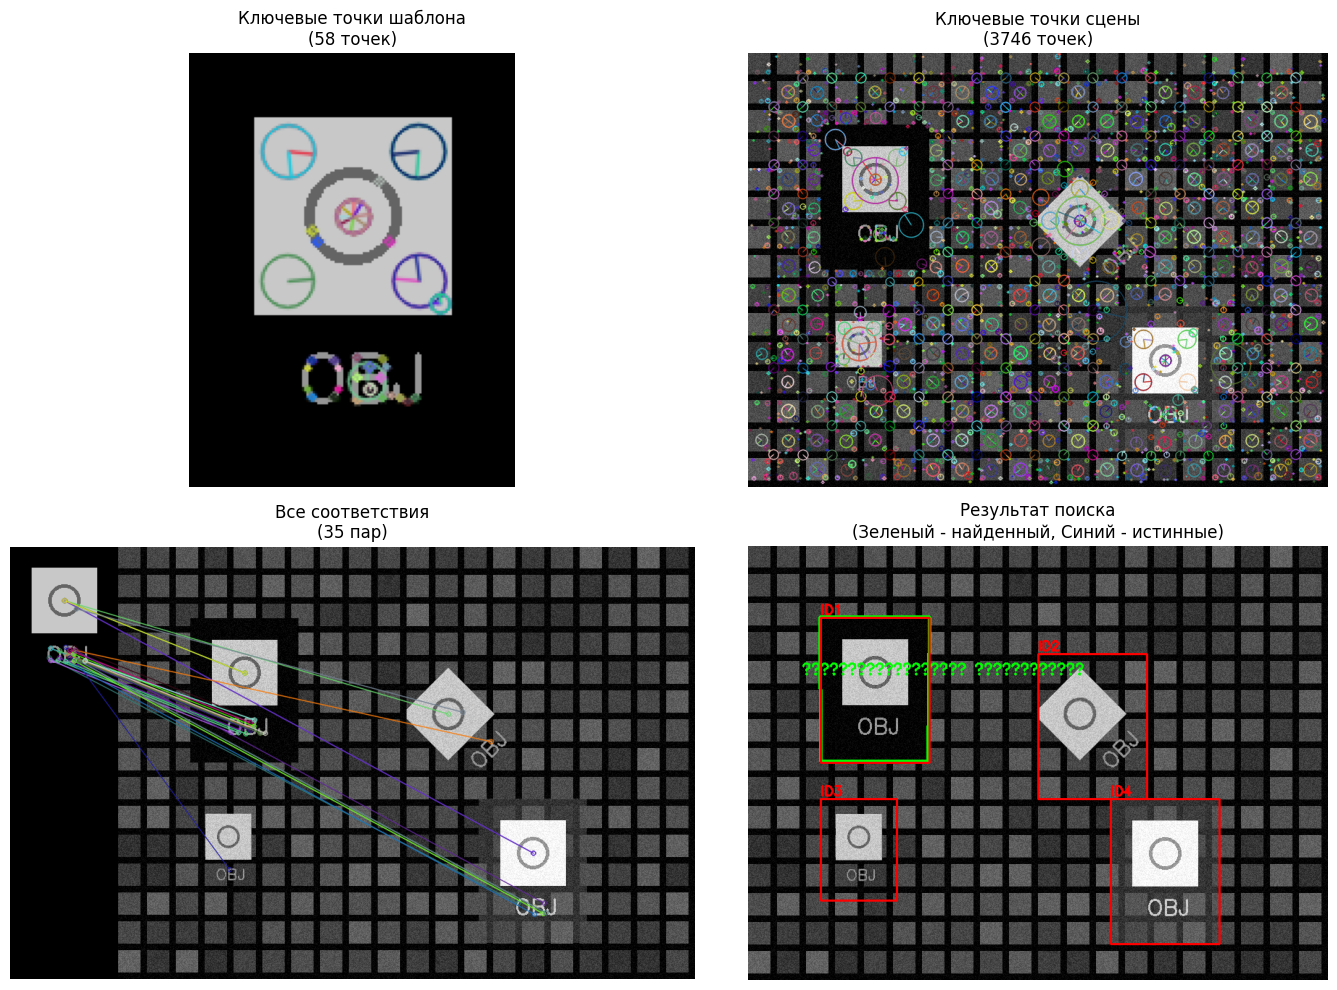


 АНАЛИЗ ТОЧНОСТИ ПОИСКА:
  Ближайший истинный объект: ID1
  Расстояние до центра: 1.7 пикселей
  Трансформация объекта: original
  IoU (перекрытие): 0.979
 Объект успешно найден!


In [10]:
# ============================================
# 3. МИНИ-ПРОЕКТ: ПОИСК ОБЪЕКТА НА СЦЕНЕ
# ============================================

def object_detection_pipeline():

    print("\n" + "="*60)
    print("МИНИ-ПРОЕКТ: ПОИСК ОБЪЕКТА НА СЦЕНЕ")
    print("="*60)

    # Создаем или загружаем изображения
    # Объект для поиска (шаблон)
    template = np.zeros((200, 150), dtype=np.uint8)
    cv2.rectangle(template, (30, 30), (120, 120), 200, -1)
    cv2.circle(template, (75, 75), 20, 100, 3)
    cv2.putText(template, 'OBJ', (50, 160), cv2.FONT_HERSHEY_SIMPLEX, 1, 150, 2)

    # Сцена с несколькими объектами
    scene = np.zeros((600, 800), dtype=np.uint8)

    # Добавляем фон
    for i in range(20):
        for j in range(15):
            intensity = np.random.randint(50, 100)
            cv2.rectangle(scene, (i*40, j*40), (i*40+30, j*40+30), intensity, -1)

    # Добавляем наш объект в разных местах с разными трансформациями
    object_positions = []

    # 1. Объект 1 (без трансформации)
    x1, y1 = 100, 100
    scene[y1:y1+200, x1:x1+150] = template
    object_positions.append({'id': 1, 'x': x1, 'y': y1, 'w': 150, 'h': 200, 'transform': 'original'})

    # 2. Объект 2 (повернутый)
    x2, y2 = 400, 150
    M = cv2.getRotationMatrix2D((75, 100), 45, 1.0)
    template_rotated = cv2.warpAffine(template, M, (150, 200))
    scene[y2:y2+200, x2:x2+150] = np.maximum(scene[y2:y2+200, x2:x2+150], template_rotated)
    object_positions.append({'id': 2, 'x': x2, 'y': y2, 'w': 150, 'h': 200, 'transform': 'rotated 45°'})

    # 3. Объект 3 (масштабированный)
    x3, y3 = 100, 350
    template_scaled = cv2.resize(template, None, fx=0.7, fy=0.7)
    h3, w3 = template_scaled.shape
    scene[y3:y3+h3, x3:x3+w3] = np.maximum(scene[y3:y3+h3, x3:x3+w3], template_scaled)
    object_positions.append({'id': 3, 'x': x3, 'y': y3, 'w': w3, 'h': h3, 'transform': 'scaled 0.7x'})

    # 4. Объект 4 (с измененной яркостью)
    x4, y4 = 500, 350
    template_bright = np.clip(template.astype(np.int16) + 50, 0, 255).astype(np.uint8)
    scene[y4:y4+200, x4:x4+150] = np.maximum(scene[y4:y4+200, x4:x4+150], template_bright)
    object_positions.append({'id': 4, 'x': x4, 'y': y4, 'w': 150, 'h': 200, 'transform': 'brightened'})

    # Добавляем немного шума
    noise = np.random.randint(-20, 20, scene.shape, dtype=np.int16)
    scene = np.clip(scene.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Визуализируем исходные данные
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(template, cmap='gray')
    axes[0].set_title('Шаблон объекта')
    axes[0].axis('off')

    axes[1].imshow(scene, cmap='gray')
    axes[1].set_title('Сцена с объектами')
    axes[1].axis('off')

    # Показываем истинные положения объектов
    for obj in object_positions:
        rect = plt.Rectangle((obj['x'], obj['y']), obj['w'], obj['h'],
                            fill=False, color='green', linewidth=2)
        axes[1].add_patch(rect)
        axes[1].text(obj['x'], obj['y']-5, f"ID{obj['id']}",
                    color='green', fontsize=10, weight='bold')

    plt.tight_layout()
    plt.show()

    # Инициализируем детектор (используем SIFT)
    try:
        detector = cv2.SIFT_create()
    except:
        try:
            detector = cv2.ORB_create()
        except:
            print("Нет доступных детекторов")
            return

    # Находим ключевые точки в шаблоне и сцене
    kp_template, des_template = detector.detectAndCompute(template, None)
    kp_scene, des_scene = detector.detectAndCompute(scene, None)

    print(f"Найдено ключевых точек:")
    print(f"  Шаблон: {len(kp_template)}")
    print(f"  Сцена: {len(kp_scene)}")

    if des_template is None or des_scene is None:
        print(" Не удалось найти ключевые точки")
        return

    # Сопоставляем дескрипторы с использованием FLANN
    if isinstance(detector, cv2.SIFT):
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50)
        norm = cv2.NORM_L2
    else:
        FLANN_INDEX_LSH = 6
        index_params = dict(algorithm=FLANN_INDEX_LSH, table_number=6,
                           key_size=12, multi_probe_level=1)
        search_params = dict(checks=50)
        norm = cv2.NORM_HAMMING

    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Выполняем knnMatch с k=2 для теста отношения Лоу
    matches = flann.knnMatch(des_template, des_scene, k=2)

    # Применяем тест отношения Лоу
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    print(f"Найдено хороших соответствий: {len(good_matches)}")

    if len(good_matches) < 10:
        print("Недостаточно хороших соответствий для определения объекта")
        return

    # Извлекаем координаты соответствий
    src_pts = np.float32([kp_template[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Применяем RANSAC для нахождения гомографии
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if M is None:
        print("Не удалось найти гомографию")
        return

    # Определяем inliers
    matches_mask = mask.ravel().tolist()
    inlier_count = sum(matches_mask)
    print(f"Inliers после RANSAC: {inlier_count} ({inlier_count/len(good_matches):.1%})")

    # Получаем координаты углов шаблона
    h, w = template.shape
    template_corners = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)

    # Проецируем углы шаблона на сцену
    scene_corners = cv2.perspectiveTransform(template_corners, M)

    # Визуализируем результаты
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Все ключевые точки на шаблоне
    img_template_kp = cv2.drawKeypoints(template, kp_template, None,
                                        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    axes[0, 0].imshow(img_template_kp)
    axes[0, 0].set_title(f'Ключевые точки шаблона\n({len(kp_template)} точек)')
    axes[0, 0].axis('off')

    # 2. Все ключевые точки на сцене
    img_scene_kp = cv2.drawKeypoints(scene, kp_scene, None,
                                     flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    axes[0, 1].imshow(img_scene_kp)
    axes[0, 1].set_title(f'Ключевые точки сцены\n({len(kp_scene)} точек)')
    axes[0, 1].axis('off')

    # 3. Все соответствия
    img_all_matches = cv2.drawMatches(template, kp_template, scene, kp_scene,
                                      good_matches, None,
                                      flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    axes[1, 0].imshow(img_all_matches)
    axes[1, 0].set_title(f'Все соответствия\n({len(good_matches)} пар)')
    axes[1, 0].axis('off')

    # 4. Результат поиска объекта
    img_result = cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB)

    # Рисуем ограничивающий прямоугольник
    scene_corners_int = np.int32(scene_corners)
    cv2.polylines(img_result, [scene_corners_int], True, (0, 255, 0), 3)

    # Подписываем объект
    centroid = np.mean(scene_corners_int, axis=0).flatten()
    cv2.putText(img_result, 'НАЙДЕННЫЙ ОБЪЕКТ',
                (int(centroid[0])-100, int(centroid[1])-20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Также показываем истинные положения объектов для сравнения
    for obj in object_positions:
        cv2.rectangle(img_result,
                     (obj['x'], obj['y']),
                     (obj['x']+obj['w'], obj['y']+obj['h']),
                     (255, 0, 0), 2)
        cv2.putText(img_result, f"ID{obj['id']}",
                   (obj['x'], obj['y']-5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    axes[1, 1].imshow(img_result)
    axes[1, 1].set_title('Результат поиска\n(Зеленый - найденный, Синий - истинные)')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Анализ точности
    print("\n АНАЛИЗ ТОЧНОСТИ ПОИСКА:")

    # Вычисляем центр найденного объекта
    found_center = centroid

    # Находим ближайший истинный объект
    min_distance = float('inf')
    nearest_obj = None

    for obj in object_positions:
        obj_center = np.array([obj['x'] + obj['w']/2, obj['y'] + obj['h']/2])
        distance = np.linalg.norm(found_center - obj_center)

        if distance < min_distance:
            min_distance = distance
            nearest_obj = obj

    if nearest_obj:
        print(f"  Ближайший истинный объект: ID{nearest_obj['id']}")
        print(f"  Расстояние до центра: {min_distance:.1f} пикселей")
        print(f"  Трансформация объекта: {nearest_obj['transform']}")

        # Проверяем перекрытие bounding boxes
        found_rect = scene_corners_int.reshape(4, 2)
        found_x_min = np.min(found_rect[:, 0])
        found_x_max = np.max(found_rect[:, 0])
        found_y_min = np.min(found_rect[:, 1])
        found_y_max = np.max(found_rect[:, 1])

        true_rect = [nearest_obj['x'], nearest_obj['y'],
                    nearest_obj['x']+nearest_obj['w'],
                    nearest_obj['y']+nearest_obj['h']]

        # Вычисляем IoU (Intersection over Union)
        x_overlap = max(0, min(found_x_max, true_rect[2]) - max(found_x_min, true_rect[0]))
        y_overlap = max(0, min(found_y_max, true_rect[3]) - max(found_y_min, true_rect[1]))

        intersection = x_overlap * y_overlap
        found_area = (found_x_max - found_x_min) * (found_y_max - found_y_min)
        true_area = nearest_obj['w'] * nearest_obj['h']
        union = found_area + true_area - intersection

        iou = intersection / union if union > 0 else 0

        print(f"  IoU (перекрытие): {iou:.3f}")

        if iou > 0.3:
            print(" Объект успешно найден!")
        else:
            print(" Объект найден неточно")

    return {
        'template': template,
        'scene': scene,
        'kp_template': kp_template,
        'kp_scene': kp_scene,
        'good_matches': good_matches,
        'homography': M,
        'found_corners': scene_corners_int
    }

# Запускаем мини-проект
object_detection_result = object_detection_pipeline()
